 K-Means Kümeleme (Clustering) Algoritması

#1. Temel Tanım:

 Gözetimsiz Öğrenme (Unsupervised Learning) algoritmasıdır (Hedef değişken/y yoktur).
 Benzer veri noktalarını birbirine yakın gruplara (kümelere) ayırır.
 Veriyi 'K' adet kümeye böler. Her kümenin bir 'Centroid' (merkez noktası) vardır.

#2. Çalışma Mantığı (Adım Adım):

1. Rastgele 'K' adet merkez (centroid) seçilir.
2. Her veri noktası, kendisine en yakın olan merkeze atanır (Öklid mesafesi kullanılır).
3. Kümelerin yeni merkezleri (centroid), içindeki noktaların ortalaması alınarak güncellenir.
4. Merkezlerin yeri değişmeyene (algoritma yakınsayana) kadar 2 ve 3. adımlar tekrarlanır.

#3. En Uygun 'K' Sayısını Bulma Yöntemleri 

 Elbow Method (Dirsek Yöntemi): WCSS (Inertia) değerinin kırılma/dirsek yaptığı K seçilir.
 Silhouette Score: Küme içi benzerlik ile kümeler arası uzaklığı kıyaslar (-1 ile +1 arası).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('26-customer_data.csv')

In [4]:
df.head()

,Annual_Income,Spending_Score
0,-5.772478,-4.818216
1,6.768246,-5.424570
2,5.796159,-6.239967
3,7.096022,-5.272612
4,-5.725561,-9.316889


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Annual_Income   1499 non-null   float64
 1   Spending_Score  1499 non-null   float64
dtypes: float64(2)
memory usage: 23.6 KB


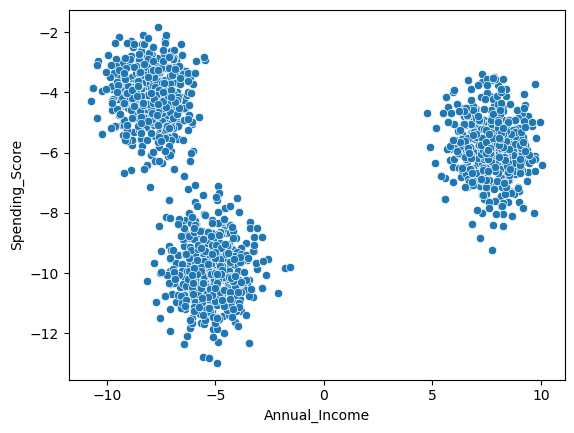

In [6]:
sns.scatterplot(data=df,x='Annual_Income',y='Spending_Score')
plt.show()

In [7]:
from sklearn.model_selection import train_test_split

In [8]:
X_train,X_test = train_test_split(df,test_size=0.2,random_state=15)

In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

X_train_scaler = scaler.fit_transform(X_train)
X_test_scaler = scaler.transform(X_test)

In [10]:
from sklearn.cluster import KMeans

In [11]:
# ELBOW METHOD

import warnings
warnings.filterwarnings('ignore')
wcss=[]
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,init='k-means++')
    kmeans.fit(X_train_scaler)
    wcss.append(kmeans.inertia_)

Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Users\PC\anaconda3\Lib\threading.py", line 1043, in _bootstrap_inner
    self.run()
    ~~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\site-packages\ipykernel\ipkernel.py", line 766, in run_closure
    _threading_Thread_run(self)
    ~~~~~~~~~~~~~~~~~~~~~^^^^^^
  File "C:\Users\PC\anaconda3\Lib\threading.py", line 994, in run
    self._target(*self._args, **self._kwargs)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\PC\anaconda3\Lib\subprocess.py", line 1615, in _readerthread
    buffer.append(fh.read())
                  ~~~~~~~^^
  File "C:\Users\PC\anaconda3\Lib\encodings\cp1254.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x9e in position 26: character maps to <undefined>
  File "C:\Users\PC\anaconda3\Lib\site

WCSS = her bir veri noktasının ait olduğu kümenin merkezine (centroid) olan uzaklıklarının karelerinin toplamıdır ve küme içi hatayı/dağılımı ölçer

In [12]:
kmeans.labels_

array([1, 3, 9, ..., 2, 7, 6], dtype=int32)

In [13]:
kmeans.inertia_

4.089200074341125

In [14]:
wcss

[196.92068784710153,
 68.44836482219307,
 11.697030239519936,
 9.90309484161272,
 7.808868079302212,
 7.29733582971236,
 5.508042553398935,
 4.95339978788679,
 4.650704506707657,
 4.089200074341125]

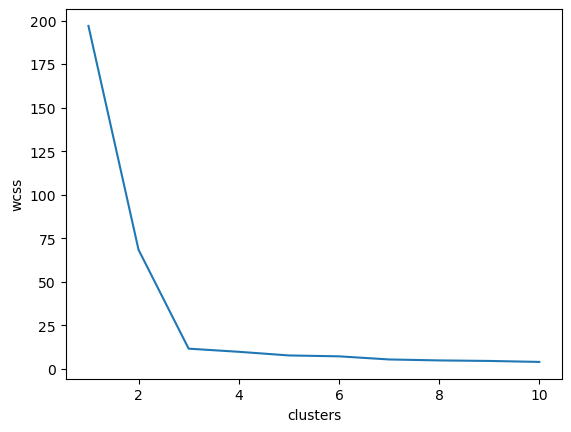

In [15]:
plt.plot(range(1,11),wcss)
plt.xlabel('clusters')
plt.ylabel('wcss')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=3)

In [17]:
kmeans.fit(X_train_scaler)

KMeans(n_clusters=3)

In [18]:
y_pred  = kmeans.predict(X_test_scaler)

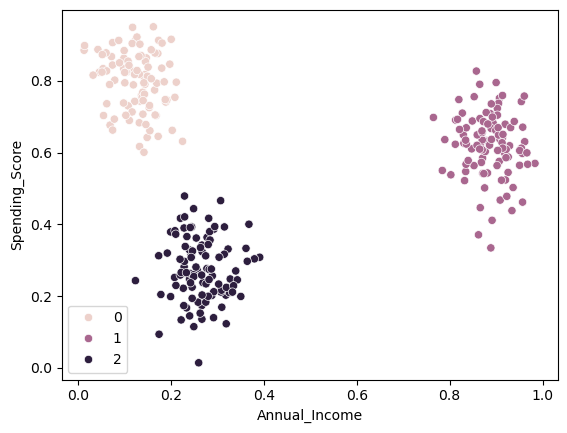

In [19]:
sns.scatterplot(data=pd.DataFrame(X_test_scaler,columns=X_test.columns),x='Annual_Income',y='Spending_Score',hue=y_pred)
plt.show()

In [20]:
!pip install kneed

In [21]:
from kneed import KneeLocator

In [22]:
kl = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')

In [23]:
kl.elbow

np.int64(3)


 KneeLocator: 2 Saniyede Parametre Seçimi


 1. CURVE (Şekil)
 - 'convex'  : Grafik AŞAĞI doğru çukurlaşıyorsa (Çanak / U şekli)
 - 'concave' : Grafik YUKARI doğru tepe yapıyorsa (Kubbe / Ters U şekli)

 2. DIRECTION (Yön)
 - 'decreasing' : X arttıkça grafik AŞAĞI iniyorsa
 - 'increasing' : X arttıkça grafik YUKARI çıkıyorsa


 HIZLI ÖZET (En Çok Kullanılanlar)

 K-Means (WCSS/Inertia) : curve='convex',  direction='decreasing'
 PCA (Varyans)          : curve='concave', direction='increasing'
 Silhouette Score       : curve='concave', direction='increasing'
 DBSCAN (k-distance)    : curve='convex',  direction='increasing'

SILHOUTTE SCORE

veri noktalarının kendi kümesine ne kadar yakın, diğer kümelere ne kadar uzak olduğunu -1 ile +1 arasında ölçerek kümelemenin kalitesini gösteren metriktir (1'e ne kadar yakınsa kümeleme o kadar başarılıdır).

In [24]:
from sklearn.metrics import silhouette_score

In [25]:
silhouette_scores = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    kmeans.fit(X_train_scaler)
    score = silhouette_score(X_train_scaler, kmeans.labels_)
    silhouette_scores.append(score)

In [27]:
silhouette_scores

[np.float64(0.6538372460771634),
 np.float64(0.7856941696336582),
 np.float64(0.6543264512565816),
 np.float64(0.5110353307041757),
 np.float64(0.39464711741379876),
 np.float64(0.382371910291844),
 np.float64(0.3615678233859731),
 np.float64(0.3414617727654833),
 np.float64(0.3457908244235177)]

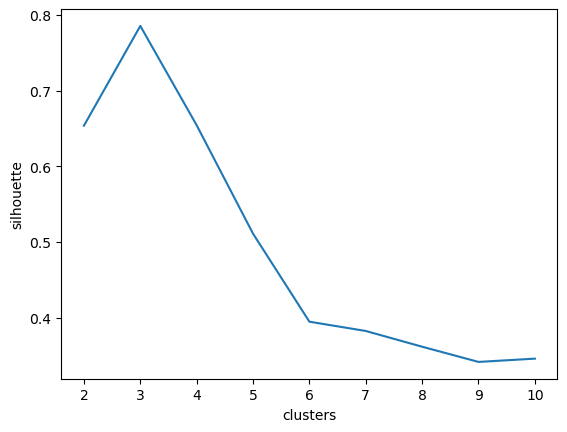

In [30]:
plt.plot(range(2,11),silhouette_scores)
plt.xticks(range(2,11))
plt.xlabel('clusters')
plt.ylabel('silhouette')
plt.show()

In [31]:
# ==============================================================
# Kümeleme Performans Metrikleri (Clustering Metrics)
# ==============================================================

# 1. İçsel (Internal) Metrikler - Gerçek Etiket (y) Yaratılmadığında Kullanılır:
# --------------------------------------------------------------
# - WCSS / Inertia (In-Cluster Sum of Squares):
#   * Küme içi uzaklık kareleri toplamıdır. Küçük olması istenir (Elbow yönteminde kullanılır).
#
# - Silhouette Score (-1 ile +1 arası):
#   * Küme içi sıkılık ile kümeler arası ayrışmayı ölçer. 1'e yakın olması en idealdir.
#
# - Davies-Bouldin Index:
#   * Kümeler arası benzerliği ölçer. DÜŞÜK skorlar daha iyi kümelemeyi gösterir.
#
# - Calinski-Harabasz Index (Variance Ratio Criterion):
#   * Kümeler arası dağılımın küme içi dağılıma oranıdır. YÜKSEK skorlar daha iyidir.

# 2. Dışsal (External) Metrikler - Gerçek Etiketler (y) Biliniyorsa Kullanılır:
# --------------------------------------------------------------
# - Adjusted Rand Index (ARI):
#   * Tahmin edilen kümeler ile gerçek sınıfların çakışmasını ölçer (-1 ile +1 arası).
#
# - Normalized Mutual Information (NMI):
#   * Tahmin ve gerçek etiketler arasındaki bilgi paylaşımını ölçer (0 ile 1 arası).